# Persistent Ising model

**References**:

[1] M. Kumar and C. Dasgupta, Nonequilibrium phase transition in an Ising model without detailed balance, Phys. Rev. E 102, 052111 (2020).


In [ ]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', 'simulation'))
if module_path not in sys.path:
    sys.path.append(module_path)

# download large dataset from zenodo
import urllib.request
data_path = "../data/pim_50x50.json"
zenodo_url = "https://zenodo.org/records/20047474/files/pim_50x50.json"
if not os.path.exists(data_path):
	print("Downloading full dataset from Zenodo (this may take a while)...")
	urllib.request.urlretrieve(zenodo_url, data_path)
	print("Download complete!")
else:
	print("Dataset already exists locally.")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors # for phase plot
import json
from pim_core import compute_eta_inferential, compute_eta_first_principle

# Plot setting
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'cmr10'  # Use the Computer Modern Roman font
plt.rcParams['mathtext.fontset'] = 'cm'  # Use Computer Modern for math text
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.labelsize'] = 14  # Axis labels
plt.rcParams['axes.titlesize'] = 18  # Title
plt.rcParams['xtick.labelsize'] = 14 # X tick labels
plt.rcParams['ytick.labelsize'] = 14 # Y tick labels
plt.rcParams['legend.fontsize'] = 12  # Legend

COLORS = ["#B2182B","#EFB9A2","#4D4D4D","#92C5DE","#2166AC"]
RED = "#B73B39"
BLUE = "#0065A8"
GREEN = "#7ea364"
phase_colors = [COLORS[0], COLORS[1], COLORS[3], COLORS[4]]

## Phase plot

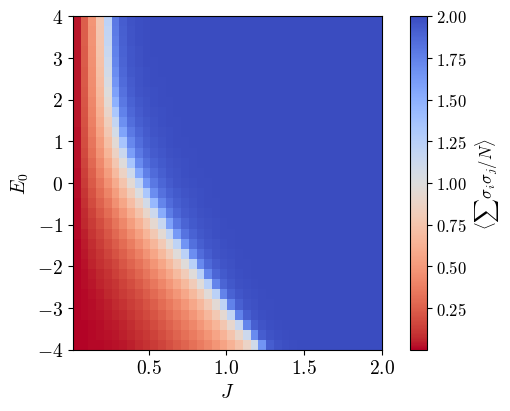

In [2]:
with open('../data/pim_phase.json', 'r') as f:
    data_phase = json.load(f)

L = data_phase['L']
N = L*L
Js = np.array(data_phase['Js'])
E0s = np.array(data_phase['E0s'])
algo = data_phase['algorithm']
mean_sum_ss = np.array(data_phase['mean_sum_ss'])/N

plt.figure(figsize=(5,4), constrained_layout=True)
plt.imshow(mean_sum_ss, aspect='auto', origin='lower',
           extent=(Js[0], Js[-1], E0s[0], E0s[-1]),
           cmap='coolwarm_r') #cmap='coolwarm_r'
plt.xlabel(r'$J$')
plt.ylabel(r'$E_0$')
# plt.title(r'Order parameter ($\langle \sum \sigma_i \sigma_j / N \rangle$)', fontsize=12)

cbar = plt.colorbar()
cbar.set_label(r'$\langle \sum \sigma_i \sigma_j / N \rangle$', fontsize=12)
cbar.ax.tick_params(labelsize=12)

In [2]:
with open('../data/pim_50x50.json', 'r') as f:
    data = json.load(f)

L = data['L']
N = L*L
Js = np.array(data['Js'])
E0s = np.array(data['E0s'])
algo = data['algorithm']
mean_sum_ss = np.array(data['mean_sum_ss'])/N
# var_sum_ss = np.array(data['var_sum_ss'])/N
# cov_s_ss = np.array(data['cov_s_ss'])/N
# px_2D = np.array(data['px_2D']) # shape (len(E0s), len(Js), L, L) - probability of each configuration at each (E0, J) point

# Identify critical control parameter values
# when conjugate observable is most sensitive to control parameter
susceptibility = np.gradient(mean_sum_ss, Js, axis=1)
peaks = np.argmax(susceptibility, axis=1)
critical_J = Js[peaks]

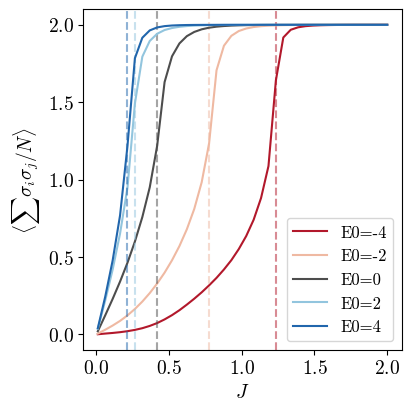

In [ ]:
# plot order parameter vs J for different E0
plt.figure(figsize=(4,4), constrained_layout=True)
for i, E0 in enumerate(E0s):
    plt.plot(Js, mean_sum_ss[i], label=f'E0={E0:.0f}', color=COLORS[i])
    plt.axvline(critical_J[i], color=COLORS[i], linestyle='--', alpha=0.5)
plt.xlabel(r'$J$')
plt.ylabel(r'$\langle \sum \sigma_i \sigma_j /N \rangle$')
plt.legend();

## Efficiencies

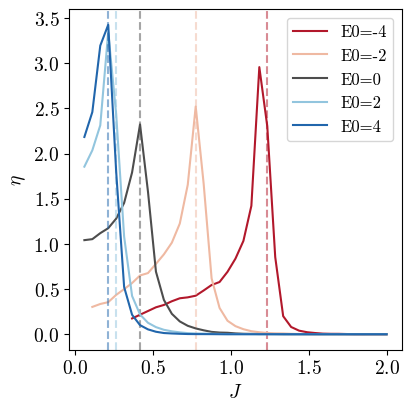

In [3]:
# Thermodynamic efficiency for different E0, first principles
eta = compute_eta_first_principle(data) 

plt.figure(figsize=(4,4), constrained_layout=True)
for i, E0 in enumerate(E0s):
    plt.plot(Js, eta[i], label=f'E0={E0:.0f}', color=COLORS[i])
    plt.axvline(critical_J[i], color=COLORS[i], linestyle='--', alpha=0.5)
plt.xlabel(r'$J$')
plt.ylabel(r'$\eta$')
plt.legend();

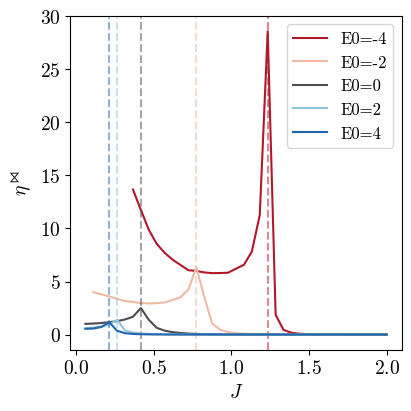

In [3]:
# Inferential efficiency for different E0
eta_infer, theta, numerator_2D, denominator_2D = compute_eta_inferential(data) # compute eta for input in the form of (E0, hs) or (E0, Js)
# eta_infer = np.where(mask, eta_infer, np.nan)

plt.figure(figsize=(4,4), constrained_layout=True)
for i, E0 in enumerate(E0s):
    plt.plot(Js, eta_infer[i], label=f'E0={E0:.0f}', color=COLORS[i])
    plt.axvline(critical_J[i], color=COLORS[i], linestyle='--', alpha=0.5)
plt.xlabel(r'$J$')
plt.ylabel(r'$\eta^\bowtie$')
plt.legend();